# Training loss: 1024 vs 8196 MLP across probe layers

Ten networks: layers {1, 8, 16, 24, 32} x widths {1024, 8196}, same aligned 50k-prompt
store, same 2-layer SiLU MLP, same cosine DDPM schedule.

- **Red family = 1024-wide**, **blue family = 8196-wide**
- Within each family, deeper layer -> darker shade (layer 1 lightest, layer 32 darkest)
- Loss is the epsilon-MSE training loss (`split == "train"` records in `train.jsonl`)
- Logs taken after the last `lr_retry` event when a run was restarted at half LR

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
LAYERS = [1, 8, 16, 24, 32]
RUNS = {
    "1024": ROOT / "runs/mlp1024/logs",
    "8196": ROOT / "logs",
}

def load_train_loss(log_dir: Path, layer: int):
    recs = [json.loads(x) for x in (log_dir / f"layer_{layer:02d}" / "train.jsonl").read_text().splitlines()]
    last_retry = max((i for i, r in enumerate(recs) if r.get("event") == "lr_retry"), default=-1)
    tr = [r for r in recs[last_retry + 1:] if r.get("split") == "train"]
    steps = np.array([r["step"] for r in tr])
    loss = np.array([r["loss"] for r in tr])
    order = np.argsort(steps)
    return steps[order], loss[order]

curves = {(w, l): load_train_loss(d, l) for w, d in RUNS.items() for l in LAYERS}
for (w, l), (s, y) in sorted(curves.items()):
    print(f"{w} L{l:<2} {len(s):>4} pts  step<= {s.max():>6}  loss [{y.min():.3f}, {y.max():.3f}]")

1024 L1  1000 pts  step<=  50000  loss [0.336, 0.570]
1024 L8  1000 pts  step<=  50000  loss [0.356, 0.536]
1024 L16 1000 pts  step<=  50000  loss [0.337, 0.533]
1024 L24 1000 pts  step<=  50000  loss [0.364, 0.534]
1024 L32 1000 pts  step<=  50000  loss [0.332, 0.526]
8196 L1  1000 pts  step<=  50000  loss [0.351, 0.562]
8196 L8  1000 pts  step<=  50000  loss [0.343, 0.521]
8196 L16 1000 pts  step<=  50000  loss [0.342, 0.513]
8196 L24 1000 pts  step<=  50000  loss [0.343, 0.520]
8196 L32 1000 pts  step<=  50000  loss [0.336, 0.526]


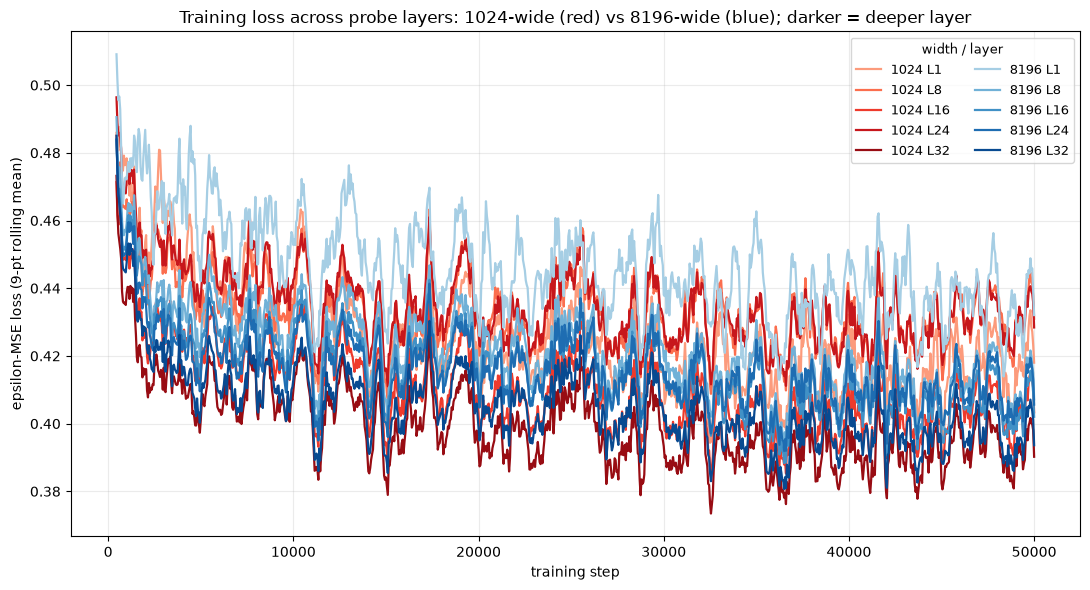

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
shades = np.linspace(0.35, 0.9, len(LAYERS))
cmap = {"1024": plt.cm.Reds, "8196": plt.cm.Blues}

for width in ("1024", "8196"):
    for shade, layer in zip(shades, LAYERS):
        steps, loss = curves[(width, layer)]
        smooth = np.convolve(loss, np.ones(9) / 9, mode="valid")
        ax.plot(steps[8:], smooth, color=cmap[width](shade), lw=1.6,
                label=f"{width} L{layer}")

ax.set_xlabel("training step")
ax.set_ylabel("epsilon-MSE loss (9-pt rolling mean)")
ax.set_title("Training loss across probe layers: 1024-wide (red) vs 8196-wide (blue); darker = deeper layer")
ax.legend(ncol=2, fontsize=9, title="width / layer", title_fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "training_loss.png", dpi=160)
plt.show()

Notes: the 1024 runs bottom out earlier (val-selected best checkpoints sit at 4k-17k steps)
while the 8196 runs keep improving to 37k-40.5k. Deeper-layer curves sit lower for 8196
(more capacity), except layer 1 where the two widths are essentially tied.